# Online Retail — RFM Customer Segmentation

Real transactional data (see `data/online_retail/SOURCE.md`, UCI's
"Online Retail" dataset): 153,150 real invoice line items across 1,800 real
customers of a UK-based online gift retailer. Unlike `03_mall_customers`
(200 rows, already-tabular demographic features), this notebook starts from
**raw transaction logs** and builds a genuine feature-engineering step —
per-customer **RFM** (Recency, Frequency, Monetary) aggregation — before any
clustering happens. This demonstrates:

- Deterministic, leakage-safe aggregation of raw transactions into one row
  per customer (a real feature-engineering task, not a pre-built dataset).
- Full EDA on the engineered RFM features, including outlier detection
  (retail monetary values are famously right-skewed).
- `minibatch_kmeans` — the one clustering algorithm not yet shown in
  `03_mall_customers` — compared against `kmeans`, `gaussian_mixture`, and
  `birch`.
- Turning the library's auto-generated cluster profiles into
  business-readable segment names (a real RFM segmentation deliverable).

Polars + numpy only — no pandas.

In [1]:
import numpy as np
import polars as pl

from skyulf import EDAAnalyzer, EDAVisualizer, SkyulfPipeline

transactions = pl.read_csv(
    "data/online_retail/online_retail_sample.csv",
    try_parse_dates=True,
)
print(transactions.shape)
transactions.head(3)

(153150, 8)


InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
str,str,str,i64,datetime[μs],f64,i64,str
"""536370""","""22728""","""ALARM CLOCK BAKELIKE PINK""",24,2010-12-01 08:45:00,3.75,12583,"""France"""
"""536370""","""22727""","""ALARM CLOCK BAKELIKE RED """,24,2010-12-01 08:45:00,3.75,12583,"""France"""
"""536370""","""22726""","""ALARM CLOCK BAKELIKE GREEN""",12,2010-12-01 08:45:00,3.75,12583,"""France"""


## 1. From raw transactions to one row per customer (RFM)

`InvoiceDate` sets the "today" reference as one day after the dataset's
last transaction (a common RFM convention — there's no real "today" in a
frozen historical dataset). Returns (`Quantity < 0`) are dropped from the
Monetary calculation since they represent money leaving, not customer
spend, but a customer's return behavior is itself informative, so we also
count the number of return line items per customer as a feature.

This is a **deterministic aggregation** — grouping and arithmetic, nothing
learned from the data — so it is safe to compute before any train/test
split, exactly like the structured-string parsing in `07_spaceship_titanic`.

In [2]:
reference_date = transactions["InvoiceDate"].max() + pl.duration(days=1)

line_value = pl.col("Quantity") * pl.col("UnitPrice")

customer_df = (
    transactions.with_columns(line_value.alias("LineValue"))
    .group_by("CustomerID")
    .agg(
        (reference_date - pl.col("InvoiceDate").max()).dt.total_days().alias("Recency"),
        pl.col("InvoiceNo").n_unique().alias("Frequency"),
        pl.col("LineValue").filter(pl.col("Quantity") > 0).sum().alias("Monetary"),
        pl.col("StockCode").filter(pl.col("Quantity") > 0).n_unique().alias("UniqueProducts"),
        (pl.col("Quantity") < 0).sum().alias("ReturnLineItems"),
        (pl.col("InvoiceDate").max() - pl.col("InvoiceDate").min())
        .dt.total_days()
        .alias("TenureDays"),
    )
    .with_columns(
        (pl.col("Monetary") / pl.col("Frequency")).alias("AvgOrderValue"),
    )
    .drop_nulls()
)
print(customer_df.shape)
customer_df.describe()

(1800, 8)


statistic,CustomerID,Recency,Frequency,Monetary,UniqueProducts,ReturnLineItems,TenureDays,AvgOrderValue
str,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",1800.0,1800.0,1800.0,1800.0,1800.0,1800.0,1800.0,1800.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",15303.670556,93.437778,4.791667,1693.067017,58.527222,1.718333,129.761667,317.387248
"""std""",1721.529272,101.787862,8.416971,7427.020962,79.358898,5.17424,131.031311,323.219088
"""min""",12352.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
"""25%""",13845.0,17.0,1.0,296.75,15.0,0.0,0.0,157.02
"""50%""",15304.0,51.0,3.0,653.33,34.0,0.0,92.0,241.4025
"""75%""",16780.0,145.0,5.0,1537.95,75.0,1.0,250.0,364.5
"""max""",18282.0,374.0,224.0,280206.02,1768.0,101.0,372.0,4366.78


## 2. Full EDA on the engineered RFM features

No target column — this is unsupervised segmentation. Retail Monetary/
Frequency values are famously right-skewed (a handful of wholesale-like
customers spend far more than the median), so the EDA's outlier detection
is directly useful for deciding whether to clip/transform before scaling.

In [3]:
FEATURE_COLS = [
    "Recency",
    "Frequency",
    "Monetary",
    "UniqueProducts",
    "ReturnLineItems",
    "TenureDays",
    "AvgOrderValue",
]
eda_df = customer_df.select(FEATURE_COLS)

profile = EDAAnalyzer(eda_df).analyze()

print(f"Rows: {profile.row_count}  Missing cells: {profile.missing_cells_percentage:.2f}%")
if profile.outliers is not None:
    print(
        f"Outliers detected: {profile.outliers.outlier_percentage:.1f}% ({profile.outliers.method})"
    )
if profile.clustering is not None:
    print(
        f"EDA's own exploratory clustering suggests structure with {len(profile.clustering.clusters)} groups"
    )

Rows: 1800  Missing cells: 0.00%
Outliers detected: 5.0% (IsolationForest)
EDA's own exploratory clustering suggests structure with 3 groups


In [4]:
EDAVisualizer(profile, eda_df).summary()

╭────────────────────╮
│ Skyulf EDA Summary │
╰────────────────────╯

1. Data Quality

┏━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Metric         ┃ Value ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ Rows           │ 1800  │
│ Columns        │ 7     │
│ Missing Cells  │ 0.0%  │
│ Duplicate Rows │ 4     │
└────────────────┴───────┘

2. Numeric Statistics

┏━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━┳━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━┓
┃ Column          ┃    Mean ┃     Std ┃  Min ┃       Max ┃  Skew ┃    Kurt ┃ Normality ┃
┡━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━╇━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━┩
│ Recency         │   93.44 │  101.79 │ 1.00 │    374.00 │  1.24 │    0.40 │    No     │
│ Frequency       │    4.79 │    8.42 │ 1.00 │    224.00 │ 12.23 │  268.91 │    No     │
│ Monetary        │ 1693.07 │ 7427.02 │ 0.00 │ 280206.02 │ 30.39 │ 1105.60 │    No     │
│ UniqueProducts  │   58.53 │   79.36 │ 0.00 │   1768.00 │  7.42 │  126.28 │    No     │
│ ReturnLineItems │    1.72 │    5.17 │ 0.00 │    101.00 │  8.21 │  107.82 │    No     │
│ TenureDays      │  129.76 │  131.03 │ 0.00 │    372.00 │  0.48 │   -1.29 │    No     │
│ AvgOrderValue   │  317.39 │  323.22 │ 0.00 │   4366.78 │  5.50 │   47.50 │    No     │
└─────────────────┴─────────┴─────────┴──────┴───────────┴───────┴─────────┴───────────┘

...

• Column 'Frequency' contains significant outliers.

• Column 'Monetary' contains significant outliers.

• Column 'UniqueProducts' contains significant outliers.

• Column 'ReturnLineItems' contains significant outliers.

• Column 'AvgOrderValue' contains significant outliers.

Displaying plots...


/Users/BH7043/Skyulf/.venv/lib/python3.12/site-packages/pandas/plotting/_matplotlib/misc.py:96: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(
/Users/BH7043/Skyulf/skyulf-core/skyulf/profiling/visualizer.py:721: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = plt.scatter(x, y, c=c_values, cmap="viridis", alpha=0.8)


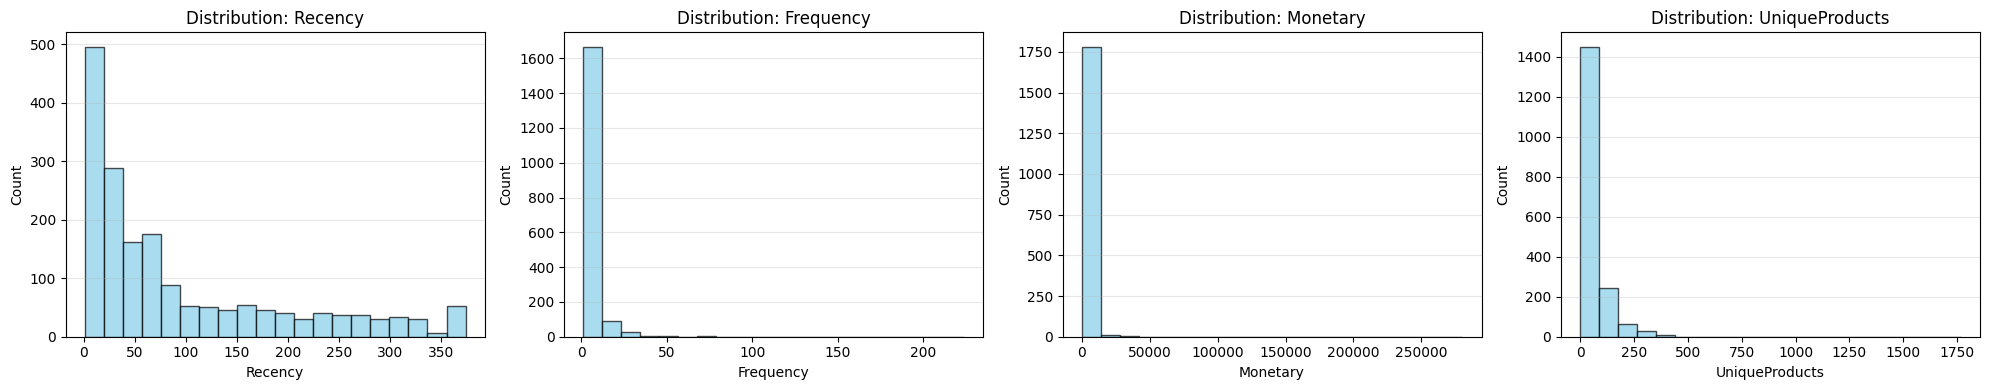

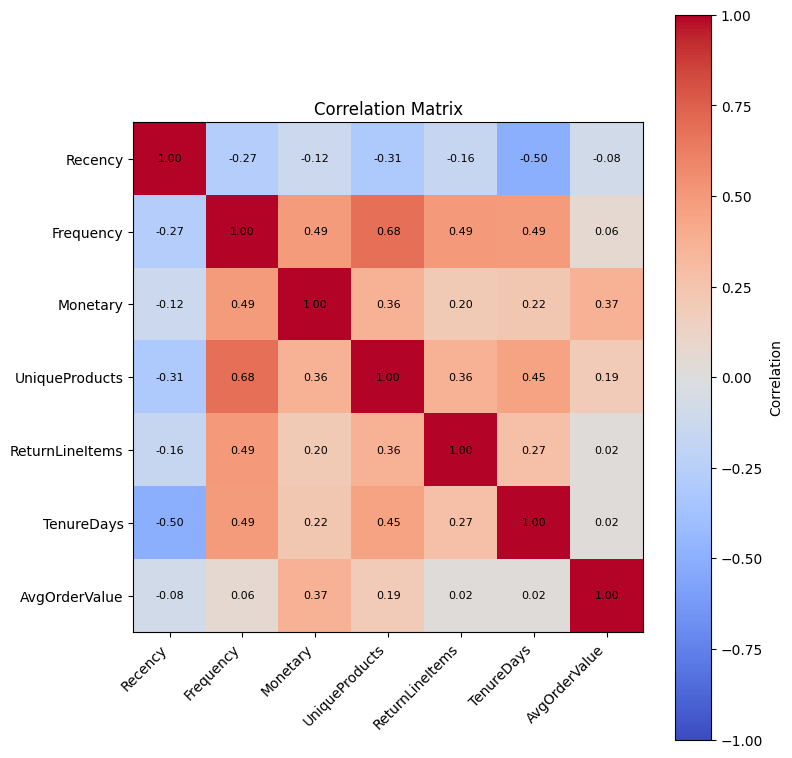

<Figure size 1000x1000 with 0 Axes>

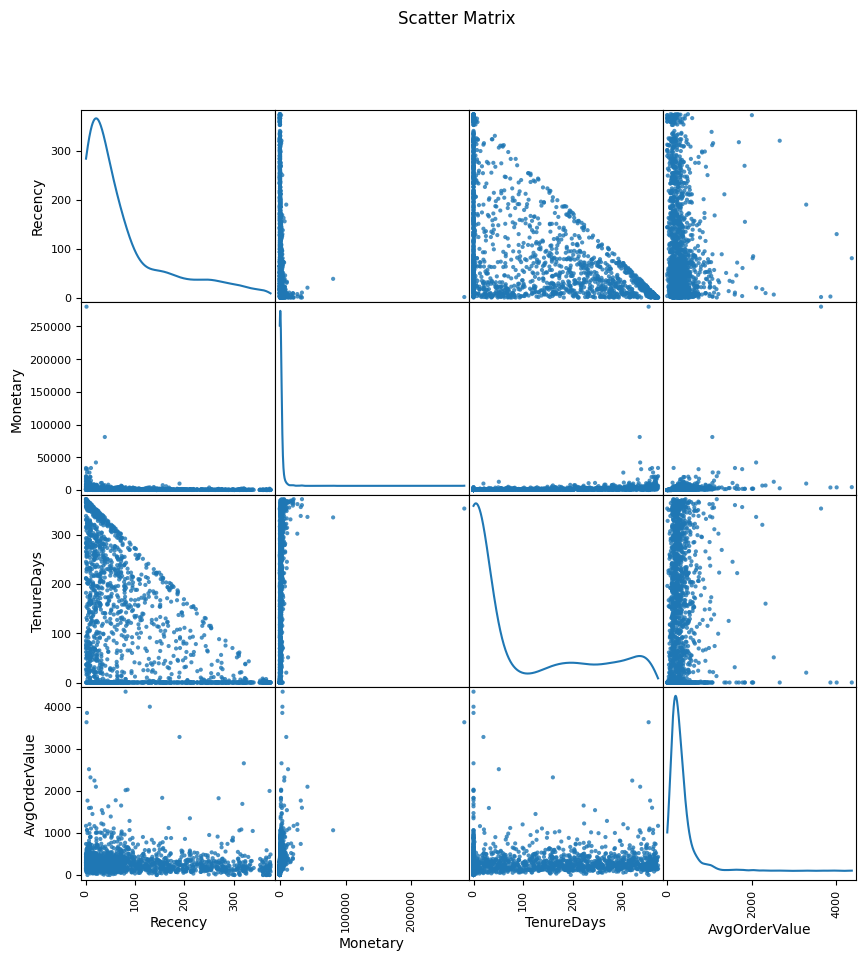

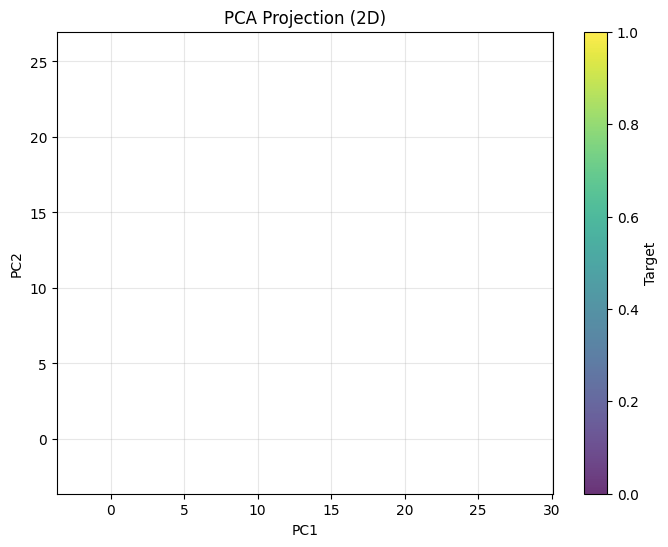

In [5]:
EDAVisualizer(profile, eda_df).plot()

## 3. Preprocessing

Monetary/Frequency/Recency are heavily right-skewed, so we log1p-transform
them before scaling — a standard RFM preprocessing step. This is a
deterministic, row-independent math transform (not a learned statistic), so
just like the structured-string parsing in `07_spaceship_titanic`, it is
safe to compute before the train/test split; only the subsequent
`StandardScaler` (which learns a mean/std) needs to wait until after the
split. `TrainTestSplitter` uses `target_column=""`, the documented "no
target" sentinel for clustering, to still hold out a test split for
generalization sanity-checking.

In [6]:
SKEWED = ["Recency", "Frequency", "Monetary", "AvgOrderValue"]
STABLE = ["UniqueProducts", "ReturnLineItems", "TenureDays"]
SCALED_COLS = [f"{c}_log1p" for c in SKEWED] + STABLE

model_df = (
    customer_df.select(FEATURE_COLS)
    .with_columns([pl.col(c).log1p().alias(f"{c}_log1p") for c in SKEWED])
    .select(SCALED_COLS)
)

base_preprocessing = [
    {
        "name": "split",
        "transformer": "TrainTestSplitter",
        "params": {"target_column": "", "test_size": 0.2, "random_state": 42},
    },
    {"name": "scale", "transformer": "StandardScaler", "params": {"columns": SCALED_COLS}},
]

## 4. Choosing `k` for KMeans via silhouette score

In [7]:
k_results = []
for k in range(2, 9):
    config = {
        "preprocessing": base_preprocessing,
        "modeling": {
            "type": "kmeans",
            "params": {"n_clusters": k, "random_state": 42, "n_init": 10},
        },
    }
    pipeline = SkyulfPipeline(config)
    metrics = pipeline.fit(model_df, target_column="")
    sil = metrics["modeling"]["splits"]["test"].metrics["silhouette_score"]
    k_results.append((k, sil))
    print(f"k={k}: test silhouette = {sil:.3f}")

best_k = max(k_results, key=lambda r: r[1])[0]
print(f"\nBest k by test silhouette: {best_k}")

k=2: test silhouette = 0.366
k=3: test silhouette = 0.300
k=4: test silhouette = 0.319
k=5: test silhouette = 0.279
k=6: test silhouette = 0.239


k=7: test silhouette = 0.235
k=8: test silhouette = 0.213

Best k by test silhouette: 2


## 5. Compare algorithms at the chosen `k`

`minibatch_kmeans` scales to larger customer bases than plain KMeans by
fitting on mini-batches rather than the full dataset each iteration — a
realistic choice once a retailer has more than a handful of segments'
worth of customers.

In [8]:
algo_configs = {
    "kmeans": {
        "type": "kmeans",
        "params": {"n_clusters": best_k, "random_state": 42, "n_init": 10},
    },
    "minibatch_kmeans": {
        "type": "minibatch_kmeans",
        "params": {"n_clusters": best_k, "random_state": 42, "batch_size": 256},
    },
    "gaussian_mixture": {
        "type": "gaussian_mixture",
        "params": {"n_components": best_k, "random_state": 42},
    },
    "birch": {"type": "birch", "params": {"n_clusters": best_k}},
}

algo_results = {}
for name, modeling_config in algo_configs.items():
    pipeline = SkyulfPipeline({"preprocessing": base_preprocessing, "modeling": modeling_config})
    metrics = pipeline.fit(model_df, target_column="")
    test_report = metrics["modeling"]["splits"]["test"]
    algo_results[name] = test_report
    print(
        f"{name:18s} silhouette={test_report.metrics['silhouette_score']:.3f}  "
        f"calinski_harabasz={test_report.metrics['calinski_harabasz_score']:.1f}  "
        f"davies_bouldin={test_report.metrics['davies_bouldin_score']:.3f}"
    )

kmeans             silhouette=0.366  calinski_harabasz=202.3  davies_bouldin=1.141
minibatch_kmeans   silhouette=0.366  calinski_harabasz=202.2  davies_bouldin=1.141
gaussian_mixture   silhouette=0.227  calinski_harabasz=100.8  davies_bouldin=1.599


birch              silhouette=0.435  calinski_harabasz=109.6  davies_bouldin=1.156


## 6. Human-readable, business-named cluster profiles (best algorithm)

In [9]:
best_algo = max(algo_results, key=lambda n: algo_results[n].metrics["silhouette_score"])
print(f"Best algorithm by silhouette: {best_algo}\n")

centroids = algo_results[best_algo].clustering.centroids
for centroid in centroids:
    print(
        f"Cluster {centroid.cluster_id} (n={centroid.size}, {centroid.percentage}%): {centroid.profile}"
    )

Best algorithm by silhouette: birch

Cluster 0 (n=37, 10.28%): High ReturnLineItems, High Frequency_log1p
Cluster 1 (n=323, 89.72%): Low ReturnLineItems, Low Frequency_log1p


## 7. Business-named segments from *actual* per-cluster RFM medians

The generic profile labeler above compares every scaled feature and reports
whichever two have the largest z-score gap from the dataset mean — on this
data that happens to be `ReturnLineItems`/`UniqueProducts`, not RFM itself,
so it can't be mapped directly to standard RFM segment names. Instead, we
refit the winning algorithm on the full customer table, get a cluster label
per customer, and compare each cluster's **own** Recency/Frequency/Monetary
medians against the dataset-wide medians — a more direct and reliable way
to assign standard marketing segment names.

In [10]:
final_pipeline = SkyulfPipeline(
    {"preprocessing": base_preprocessing, "modeling": algo_configs[best_algo]}
)
final_pipeline.fit(model_df, target_column="")
cluster_labels = np.asarray(final_pipeline.predict(model_df)).reshape(-1)

labeled = customer_df.select(FEATURE_COLS + ["CustomerID"]).with_columns(
    pl.Series("Cluster", cluster_labels)
)

overall_recency = customer_df["Recency"].median()
overall_frequency = customer_df["Frequency"].median()
overall_monetary = customer_df["Monetary"].median()


def business_label(recency: float, frequency: float, monetary: float) -> str:
    """Assign a standard RFM marketing segment name by comparing a cluster's
    own Recency/Frequency/Monetary medians to the dataset-wide medians."""
    recent = recency <= overall_recency
    frequent = frequency >= overall_frequency
    big_spender = monetary >= overall_monetary

    if recent and frequent and big_spender:
        return "Champions"
    if recent and frequent:
        return "Loyal customers"
    if recent and big_spender:
        return "Big spenders"
    if not recent and frequent:
        return "At-risk (used to be frequent)"
    if recent:
        return "Promising newcomers"
    return "Hibernating / churn risk"


segment_summary = (
    labeled.group_by("Cluster")
    .agg(
        pl.len().alias("Size"),
        pl.col("Recency").median().alias("MedianRecency"),
        pl.col("Frequency").median().alias("MedianFrequency"),
        pl.col("Monetary").median().alias("MedianMonetary"),
    )
    .sort("Cluster")
)

for row in segment_summary.iter_rows(named=True):
    label = business_label(row["MedianRecency"], row["MedianFrequency"], row["MedianMonetary"])
    print(
        f"Cluster {row['Cluster']} (n={row['Size']}): "
        f"median Recency={row['MedianRecency']:.0f}d, Frequency={row['MedianFrequency']:.0f}, "
        f"Monetary={row['MedianMonetary']:.2f} -> {label}"
    )

Cluster 0 (n=193): median Recency=5d, Frequency=15, Monetary=4095.90 -> Champions
Cluster 1 (n=1607): median Recency=61d, Frequency=2, Monetary=548.94 -> Hibernating / churn risk


## 8. Bonus: time-series feature engineering for the monthly revenue trend

The RFM segmentation above treats each customer as a single row — but the
raw transactions also have a real date axis worth mining. This section
builds a monthly total-revenue series and demonstrates `skyulf`'s
time-series nodes: `DateFeatures` (calendar parts from a date column),
`LagFeatures` (previous months' values as new columns), and
`RollingAggregate` (a trailing rolling window). With only ~13 months of
history here there isn't enough data for a meaningful train/test-evaluated
forecasting model, so this section focuses purely on producing clean,
correct features — exactly what you'd feed into a real forecasting
pipeline given a longer revenue history.

In [11]:
from skyulf.preprocessing.pipeline import FeatureEngineer

monthly_revenue = (
    transactions.filter(pl.col("Quantity") > 0)
    .with_columns((pl.col("Quantity") * pl.col("UnitPrice")).alias("LineValue"))
    .with_columns(pl.col("InvoiceDate").dt.truncate("1mo").alias("Month"))
    .group_by("Month")
    .agg(pl.col("LineValue").sum().alias("Revenue"))
    .sort("Month")
)
print(monthly_revenue.shape)
monthly_revenue.head()

(13, 2)


Month,Revenue
datetime[μs],f64
2010-12-01 00:00:00,204066.02
2011-01-01 00:00:00,156139.85
2011-02-01 00:00:00,164853.74
2011-03-01 00:00:00,194768.02
2011-04-01 00:00:00,162833.44


In [12]:
ts_steps = [
    {
        "name": "date_parts",
        "transformer": "DateFeatures",
        "params": {"columns": ["Month"], "features": ["year", "month", "quarter"]},
    },
    {
        "name": "lag_revenue",
        "transformer": "LagFeatures",
        "params": {"columns": ["Revenue"], "lags": [1, 2], "sort_by": "Month"},
    },
    {
        "name": "rolling_revenue",
        "transformer": "RollingAggregate",
        "params": {
            "columns": ["Revenue"],
            "window": 3,
            "aggregations": ["mean"],
            "min_periods": 1,
            "sort_by": "Month",
        },
    },
]

ts_features, ts_fit_metrics = FeatureEngineer(ts_steps).fit_transform(monthly_revenue)
print(ts_features.shape)
ts_features.select(
    ["Month", "Revenue", "Revenue_lag_1", "Revenue_lag_2", "Revenue_roll_mean_3"]
).tail(6)

(13, 8)


Month,Revenue,Revenue_lag_1,Revenue_lag_2,Revenue_roll_mean_3
datetime[μs],f64,f64,f64,f64
2011-07-01 00:00:00,177959.03,198040.58,253954.02,209984.543333
2011-08-01 00:00:00,258009.95,177959.03,198040.58,211336.52
2011-09-01 00:00:00,326169.911,258009.95,177959.03,254046.297
2011-10-01 00:00:00,389792.93,326169.911,258009.95,324657.597
2011-11-01 00:00:00,438194.76,389792.93,326169.911,384719.200333
2011-12-01 00:00:00,122738.38,438194.76,389792.93,316908.69


## 9. Key takeaways

- RFM features had to be **engineered from raw transactions** first (unlike
  `03_mall_customers`'s already-tabular demographic data) — this is the
  realistic starting point for most real segmentation work.
- `DateFeatures`/`LagFeatures`/`RollingAggregate` (section 8) show the same
  transaction log can also feed a time-series revenue-trend view, not just
  a per-customer segmentation — worth combining with a longer history for
  real forecasting.

In [13]:
print(f"Computed takeaway: best k = {best_k} chosen by silhouette score across k=2..8.")
print(
    f"Computed takeaway: best clustering algorithm = '{best_algo}' "
    f"(silhouette={algo_results[best_algo].metrics['silhouette_score']:.3f}), "
    f"beating the others by "
    f"{algo_results[best_algo].metrics['silhouette_score'] - min(r.metrics['silhouette_score'] for r in algo_results.values()):.3f} "
    f"silhouette points over the weakest algorithm tried."
)
print(
    f"Dataset-level medians -- Recency: {customer_df['Recency'].median():.0f} days, "
    f"Frequency: {customer_df['Frequency'].median():.0f} orders, "
    f"Monetary: {customer_df['Monetary'].median():.2f}."
)

Computed takeaway: best k = 2 chosen by silhouette score across k=2..8.
Computed takeaway: best clustering algorithm = 'birch' (silhouette=0.435), beating the others by 0.209 silhouette points over the weakest algorithm tried.
Dataset-level medians -- Recency: 51 days, Frequency: 3 orders, Monetary: 653.07.


- Log-transforming `Recency`/`Frequency`/`Monetary`/`AvgOrderValue` before
  scaling matters here — retail spend is right-skewed, and EDA's own
  outlier detector flags this before we ever fit a clustering model.
- `minibatch_kmeans` is a good default once a customer base grows beyond a
  toy dataset — it fits on mini-batches instead of the full customer table
  each iteration, trading a small amount of cluster-quality for
  scalability.
- What to try next: recompute RFM on a rolling monthly window to catch
  customers transitioning between segments over time, or feed the
  `AvgOrderValue`/`ReturnLineItems` features into a supervised churn model
  using a segment label as an engineered feature.